# One Hot Encoding

# Converting Textual Data into Numeric Data

#### Categorical Encoding is the process of converting these textual categories into numeric values.

The three most common ways to achieve this in machine learning are:

1. Label Encoding / Ordinal Encoding
     This approach converts each unique text label into a distinct integer.


    Ordinal Encoding: Used when the categorical data has an inherent order or rank (e.g., Education: High
    School = 0, Bachelors = 1, PhD = 2).


   Label Encoding: Typically used for the target variable (y) rather than features (X).
   
3. One-Hot Encoding
    This is the most widely used method for nominal data (categories with no inherent order, like Color:
    Red, Green, Blue).


   It creates a new binary column (0 or 1) for every unique category in the feature.

   Note: To avoid multi-collinearity (the dummy variable trap), we often drop one of the columns.
   
3. Target Encoding (or Mean Encoding)
    In this advanced technique, categories are replaced with a shared statistic—usually the mean of the target variable for that specific category.

   It's highly effective for high-cardinality features (features with many unique values, like Zip Codes or City Names) because it doesn't increase the dataset's dimensionality like One-Hot Encoding does.

# Program 1
### Dataset given: carprices.csv

### Applying One Dummy Variable method and One Hot Encoding 

In [226]:
import pandas as pd


df = pd.read_csv('homeprices.csv')
print(df.shape)  # Output: (50, 3)
df.head()

(50, 3)


,town,area,price
0,robbinsville,3160,626000
1,monroe township,2530,517000
2,robbinsville,2890,582000
3,robbinsville,2910,553000
4,monroe township,3660,649000


In [227]:
df.columns

Index(['town', 'area', 'price'], dtype='object')

In [228]:
df['town'].unique()

array(['robbinsville', 'monroe township', 'west windsor'], dtype=object)

In [229]:
dummies = pd.get_dummies(df.town , dtype=int)
dummies.head()

,monroe township,robbinsville,west windsor
0,0,1,0
1,1,0,0
2,0,1,0
3,0,1,0
4,1,0,0


In [230]:
# to avoid dummpy cariable trap , remove 'west windsor' 
dummies = dummies.drop(['west windsor'], axis= 1) 
dummies.head()

,monroe township,robbinsville
0,0,1
1,1,0
2,0,1
3,0,1
4,1,0


In [231]:
# add these ddummies to original df. add columns of both 
merged = pd.concat([df, dummies], axis= 1)
merged.head()

,town,area,price,monroe township,robbinsville
0,robbinsville,3160,626000,0,1
1,monroe township,2530,517000,1,0
2,robbinsville,2890,582000,0,1
3,robbinsville,2910,553000,0,1
4,monroe township,3660,649000,1,0


In [232]:
# we do not require 'town' cariable as it is replaced by dummy vars. 
# Hence drop town. 
final = merged.drop(['town'], axis=1) 
final.head()

,area,price,monroe township,robbinsville
0,3160,626000,0,1
1,2530,517000,1,0
2,2890,582000,0,1
3,2910,553000,0,1
4,3660,649000,1,0


In [233]:
# we have to delete price columns as it is the target column to be predicted 
x = final.drop(['price'], axis = 1)
x.head()

,area,monroe township,robbinsville
0,3160,0,1
1,2530,1,0
2,2890,0,1
3,2910,0,1
4,3660,1,0


In [234]:
y = final['price'] 
y.head(10)

0    626000
1    517000
2    582000
3    553000
4    649000
5    627000
6    721000
7    598000
8    600000
9    552000
Name: price, dtype: int64

In [235]:
# ecen though we do not drop the dummy variable, 
# linear regression model will work correctly. 
# The reason is it will internally drop a column. 

In [236]:
# let us create linear regression model 
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x,y) # train the model 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [237]:
# predict the price of house with 2800 sft aea located at robinsille
# parameters: 1st: area, 2nd: monroe township, 3rd: robinsille
model.predict([[2800,0,1]]) 

C:\Program Files\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([561700.58301676])

In [238]:
# pcredits the price of house with 3400 sft at west windsor 
import pandas as pd
model.predict(pd.DataFrame([[2800, 0, 1]], columns=['area', 'monroe township', 'robbinsville']))

array([561700.58301676])

In [239]:
# find the accuracy of our model. 
model.score(x,y)

0.9467249322078384

## One Hot Encoder Method
#### Two steps to apply OHE
    While that two-step method (using LabelEncoder first, then OneHotEncoder) used to be a common workaround in older versions of scikit-learn years ago, it is no longer correct or necessary.
    In modern machine learning, you should never use LabelEncoder on your feature columns before applying OneHotEncoder.
### Here is why, and how you should actually do it:
#### Why the old way is incorrect
    1. Label Encoder is for target variables (y): It is designed to encode the labels you are trying to predict, not the input features (x).
    2. OneHotEncoder handles text directly: Modern versions of scikit-learn allow OneHotEncoder to process raw text strings directly. Forcing it through a Label Encoder first is a redundant, unnecessary step.

In [240]:
df.town.head()

0       robbinsville
1    monroe township
2       robbinsville
3       robbinsville
4    monroe township
Name: town, dtype: object

In [241]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() 

# fit and transform the town column 
df.town = le.fit_transform(df.town)
df.head(13)

,town,area,price
0,1,3160,626000
1,0,2530,517000
2,1,2890,582000
3,1,2910,553000
4,0,3660,649000
5,0,3540,627000
6,1,3920,721000
7,2,2790,598000
8,1,3160,600000
9,1,2810,552000


In [242]:
x = df[['town','area']].values
y = df.price

In [243]:
# now , we should convert the 'town' values into binary digits using OneHotEncoder.

In [244]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

#To avoid the Dummy Variable Trap (multicollinearity), you need to drop one of your dummy columns.
# 1. Add drop='first' and sparse_output=False
ohe = OneHotEncoder(drop='first', sparse_output=False)

# 2. Fit and transform your data
x1 = ohe.fit_transform(df[['town']])

# 3. Convert to DataFrame (it will now only have 2 columns instead of 3)
x1 = pd.DataFrame(x1, columns=ohe.get_feature_names_out(['town']),dtype=int)
x1.head()

,town_1,town_2
0,1,0
1,0,0
2,1,0
3,1,0
4,0,0


In [245]:
# 1. Ensure x is a DataFrame (using double brackets)
x = df[['area']] 

# 2. Now concatenate x and x1 
# Make sure x is a DataFrame and combine it with your dummy columns (x1)
x = pd.concat([df[['area']], x1], axis='columns')
x.head()

,area,town_1,town_2
0,3160,1,0
1,2530,0,0
2,2890,1,0
3,2910,1,0
4,3660,0,0


In [246]:
# Now this data (x_final) can be used in any Machine Learning Model . 

In [247]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [248]:
# pcredits the price of house with 3400 sft at west windsor 
model.predict([[3400,0,0]])

C:\Program Files\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([607373.90251732])

In [249]:
model.score(x,y)

0.9467249322078384

# Program 2

## The dataset: carprices.csv

In [250]:
import pandas as pd

# Load and verify the dataset
df = pd.read_csv('carprices.csv')
df

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A6,59000,29400,5
6,Audi A6,52000,32000,5
7,Audi A6,72000,19300,6
8,Audi A6,91000,12000,8
9,Mercedez Benz C Class,67000,22000,6


### Exercise
Build the model that can answer the folling questions.  

        1. Predict price of a Mercedez Benz that is 4 yrs old mileage 4500. 
        2. Predict price of a BMW X5 that is 7 yrs old with mileage 86000. 
        3. What is the score(accuracy) of your model.

<Axes: xlabel='Age(yrs)', ylabel='Sell Price($)'>

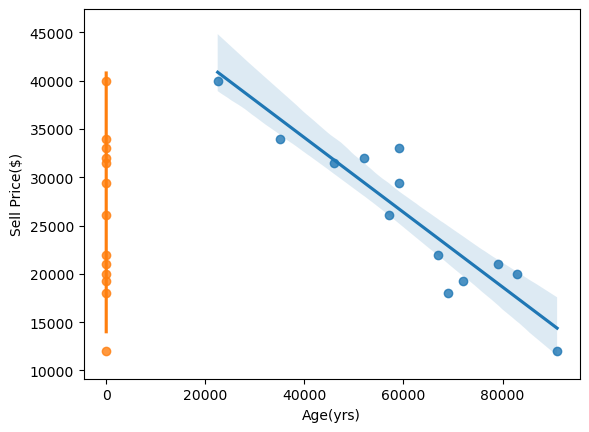

In [251]:
# check if linear regression can be used on this data set 
import seaborn as sns
sns.regplot(data=df, x= 'Mileage', y = 'Sell Price($)')
sns.regplot(data=df, x='Age(yrs)',y='Sell Price($)')

In [252]:
# They are showing approximate straight lines that means Linear Regression can be used

In [253]:
# To use one hot encoding, first we should use label encoding 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [254]:
# fit and transform the dataframe using le on Car Model column 

df['Car Model'] = le.fit_transform(df['Car Model'])
df['Car Model']

0     1
1     1
2     1
3     1
4     1
5     0
6     0
7     0
8     0
9     2
10    2
11    2
12    2
Name: Car Model, dtype: int64

In [255]:
# take independent variables or features 
x = df[['Car Model', 'Mileage', 'Age(yrs)']]
x

,Car Model,Mileage,Age(yrs)
0,1,69000,6
1,1,35000,3
2,1,57000,5
3,1,22500,2
4,1,46000,4
5,0,59000,5
6,0,52000,5
7,0,72000,6
8,0,91000,8
9,2,67000,6


In [256]:
# retrieve target or dependent variable
y = df['Sell Price($)']
y

0     18000
1     34000
2     26100
3     40000
4     31500
5     29400
6     32000
7     19300
8     12000
9     22000
10    20000
11    21000
12    33000
Name: Sell Price($), dtype: int64

In [257]:
# now apply OHE on Car Model column
from sklearn.preprocessing import OneHotEncoder
# also handle dummy bariable trap, dropping first column
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
x1 = ohe.fit_transform(df[['Car Model']])

# x1 is a sparse matrix, convert it into array and data frame 
# x1 = pd.DataFrame(x1)

x1 = pd.DataFrame(x1, columns=ohe.get_feature_names_out(['Car Model']))
x1

,Car Model_1,Car Model_2
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
5,0.0,0.0
6,0.0,0.0
7,0.0,0.0
8,0.0,0.0
9,0.0,1.0


In [258]:
x = pd.concat([x,x1], axis="columns")
x

,Car Model,Mileage,Age(yrs),Car Model_1,Car Model_2
0,1,69000,6,1.0,0.0
1,1,35000,3,1.0,0.0
2,1,57000,5,1.0,0.0
3,1,22500,2,1.0,0.0
4,1,46000,4,1.0,0.0
5,0,59000,5,0.0,0.0
6,0,52000,5,0.0,0.0
7,0,72000,6,0.0,0.0
8,0,91000,8,0.0,0.0
9,2,67000,6,0.0,1.0


In [259]:
# remove Car Model columns as it is available in encoded form (the last 2 columns)
x.drop('Car Model', axis=1, inplace=True)
x

,Mileage,Age(yrs),Car Model_1,Car Model_2
0,69000,6,1.0,0.0
1,35000,3,1.0,0.0
2,57000,5,1.0,0.0
3,22500,2,1.0,0.0
4,46000,4,1.0,0.0
5,59000,5,0.0,0.0
6,52000,5,0.0,0.0
7,72000,6,0.0,0.0
8,91000,8,0.0,0.0
9,67000,6,0.0,1.0


In [261]:
# let us create linear regression model 
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [262]:
# train the model 
model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [263]:
# Predict price of a mercedez benz that is 4 yrs old 
# mileage 45000. 
model.predict([[45000,4,0,1]])

C:\Program Files\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([36991.31721061])

In [264]:
# predict price of a BMW X5 that is 7 yrs old with mileage 86000. 
model.predict([[86000,7,1,0]])

C:\Program Files\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([11080.74313219])

In [265]:
# know the score 
model.score(x,y)

0.9417050937281083

# -- End --